# Stack Exchange question-thread EDA

**Objective.** The analysis describes one Stack Exchange community and a selected question period, identifies observable human-response patterns, and prepares concrete questions for qualitative analysis.

**Table unit.** Each row represents one question. Answer, acceptance, comment, closure, score, view, tag, and timing fields describe activity recorded in the selected dump snapshot.

**Analytical limit.** These indicators support investigation. Difficulty labels require a separate documented assessment.


## Data origin and table structure

- Stack Exchange public data dumps use XML files.
- `Posts.xml` stores questions and answers. `PostTypeId = 1` identifies a question and `PostTypeId = 2` identifies an answer.
- `Comments.xml` stores comments separately. The project counts comments attached directly to questions.
- `Votes.xml` records answer-acceptance events at calendar-day precision.
- `src/build_characteristics.py` combines these sources into one TSV table with one row per question.
- `config/characteristics.tsv` and `docs/reference/data-dictionary.xlsx` define the 49 fields, their sources, calculations, interpretations, and empty-value meanings.

The dump is a snapshot. Scores, views, answer counts, comments, and moderation events describe the state available at that snapshot.


## Upstream extraction and characteristic calculation

The EDA starts from `thread_characteristics.tsv`, produced by `src/build_characteristics.py`.

| Build parameter | Meaning and effect |
|---|---|
| `--dump-dir` | Folder containing compatible `Posts.xml`, `Comments.xml`, and `Votes.xml` files. |
| `--site` | Community host retained as provenance and used in question and answer links. |
| `--dump-date` | Snapshot date represented by the dump and latest possible observation date. |
| `--start-date`, `--end-date` | Inclusive question-creation dates used by the builder. Excluded questions cannot reappear in the notebook. |
| `--output-dir` | Destination for `thread_characteristics.tsv`, `validation.tsv`, and `run_metadata.json`. |
| `--schema` | Optional characteristic specification; the maintained default is `config/characteristics.tsv`. |
| `--limit` | Optional chronological question limit for a pilot. Omission processes the complete selected source period. |
| `--overwrite` | Explicit permission to replace the three canonical output files. |

The complete-thread and configurable-summary XML extractors remain separate routes. Their exact interfaces and outputs are documented in the project README.


## Figure design rules

Every figure follows the same declared rules:

- chart type matches the relationship: columns for monthly or annual flow counts, lines for cumulative stocks, histograms for distributions, and dot plots for comparisons;
- bars and filled quantities start at zero;
- axes are linear, use actual units, and avoid broken or dual scales;
- comparable small multiples share the same scale;
- histograms use equal-width bins and disclose the central range, excluded tail counts, and observed extremes;
- outcome groups with overlap appear separately; stacked bars are limited to answered and unanswered questions because those groups form one complete total;
- categories use no more than five colours in one figure, and marker shape, labels, or hatch patterns provide information in addition to colour;
- percentages describe the complete selected table and therefore appear without sampling-error intervals; correlation uncertainty is represented by sample-size, strength, and false-discovery-rate rules.

The rules follow the [Office for National Statistics chart principles](https://service-manual.ons.gov.uk/data-visualisation/guidance/principles), [chart-type guidance](https://service-manual.ons.gov.uk/data-visualisation/chart-types/choosing-a-chart-type), [axis guidance](https://service-manual.ons.gov.uk/data-visualisation/guidance/axes-and-gridlines), [colour guidance](https://service-manual.ons.gov.uk/data-visualisation/colours/using-colours-in-charts), the [NIST histogram definition](https://itl.nist.gov/div898/handbook/eda/section3/histogra.htm), the [NIST Tukey outlier rule](https://www.itl.nist.gov/div898/handbook/prc/section1/prc16.htm), and [W3C non-text contrast guidance](https://www.w3.org/WAI/WCAG22/Understanding/non-text-contrast).


In [1]:
# Project-relative helper imports keep preparation and plotting code outside the notebook.
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import eda_figures as charts
import eda_support as eda


## Editable settings

The following cell is the only routine editing point.

### Input and period

- **`DATA_FILE`** — characteristic TSV produced by `build_characteristics.py`.
- **`PERIOD_MODE`** — `"all"`, `"date_range"`, or `"year_range"`.
- **`START_DATE`, `END_DATE`** — inclusive `YYYY-MM-DD` limits for `date_range` mode.
- **`START_YEAR`, `END_YEAR`** — inclusive whole years for `year_range` mode.

Examples:

```python
# Every question already present in the TSV
PERIOD_MODE = "all"
START_DATE = END_DATE = None
START_YEAR = END_YEAR = None

# Explicit dates
PERIOD_MODE = "date_range"
START_DATE, END_DATE = "2023-01-01", "2023-06-30"
START_YEAR = END_YEAR = None

# Complete calendar years
PERIOD_MODE = "year_range"
START_YEAR, END_YEAR = 2022, 2024
START_DATE = END_DATE = None
```

### Outlier result and evidence rules

- **`OUTLIER_OUTPUT_FILE`** — optional TSV destination. `None` keeps `outlier_questions` in memory.
- **`MIN_TAG_QUESTIONS`** — minimum questions required for a tag percentage comparison.
- **`TOP_TAGS_TO_SHOW`** — maximum frequent tags displayed.
- **`MIN_CORRELATION_OBSERVATIONS`** — minimum complete questions required for one correlation.
- **`MIN_ABSOLUTE_RHO`** — minimum displayed absolute Spearman coefficient.
- **`FDR_ALPHA`** — false-discovery-rate limit for correlation selection.
- **`MAX_CORRELATION_PAIRS`** — maximum supported correlation pairs displayed.
- **`MAX_CASES_TO_SHOW`** — maximum rows in the final inspection table.


In [2]:
# Input table and question-period selection.
DATA_FILE = PROJECT_ROOT / "data/examples/characteristics_pilot.tsv"
PERIOD_MODE = "all"
START_DATE = None
END_DATE = None
START_YEAR = None
END_YEAR = None

# Optional separate outlier TSV.
OUTLIER_OUTPUT_FILE = None

# Evidence thresholds and display limits.
MIN_TAG_QUESTIONS = 20
TOP_TAGS_TO_SHOW = 15
MIN_CORRELATION_OBSERVATIONS = 20
MIN_ABSOLUTE_RHO = 0.30
FDR_ALPHA = 0.05
MAX_CORRELATION_PAIRS = 12
MAX_CASES_TO_SHOW = 8


## 1. Table loading and verification

Reusable helpers validate settings, required fields, data types, date order, source consistency, and the selected period before any figure is produced. A specific exception stops execution when the input does not satisfy the 49-field contract.


In [3]:
DATA_FILE, OUTLIER_OUTPUT_FILE = eda.validate_notebook_settings(
    DATA_FILE,
    OUTLIER_OUTPUT_FILE,
    min_tag_questions=MIN_TAG_QUESTIONS,
    top_tags_to_show=TOP_TAGS_TO_SHOW,
    min_correlation_observations=MIN_CORRELATION_OBSERVATIONS,
    min_absolute_rho=MIN_ABSOLUTE_RHO,
    fdr_alpha=FDR_ALPHA,
    max_correlation_pairs=MAX_CORRELATION_PAIRS,
    max_cases_to_show=MAX_CASES_TO_SHOW,
)
analysis = eda.load_questions(
    DATA_FILE,
    period_mode=PERIOD_MODE,
    start_date=START_DATE,
    end_date=END_DATE,
    start_year=START_YEAR,
    end_year=END_YEAR,
)
data = analysis.questions
display(eda.dataset_summary(analysis))
display(Markdown("**Settings and table checks:** passed."))
figure_status = []


,Item,Value
0,Site,softwareengineering.stackexchange.com
1,Rows in source TSV,20
2,Questions selected,20
3,Source columns,49
4,Requested period,All question rows in the TSV
5,Selected question dates,2024-01-01 to 2024-01-08
6,Outcome observation end,2024-01-08
7,Dump snapshot,2026-04-20


**Settings and table checks:** passed.

## 2. Figure 1 — Table coverage and overall outcomes

Figure 1a uses one common denominator: all selected questions. Answered and unanswered questions form a complete partition; accepted and closed questions are separate overlapping outcomes.

Figure 1b reports **availability**, which prevents an absent event from being misrepresented as a data-quality defect. Figure 1c reports actual source-versus-reconstruction differences.


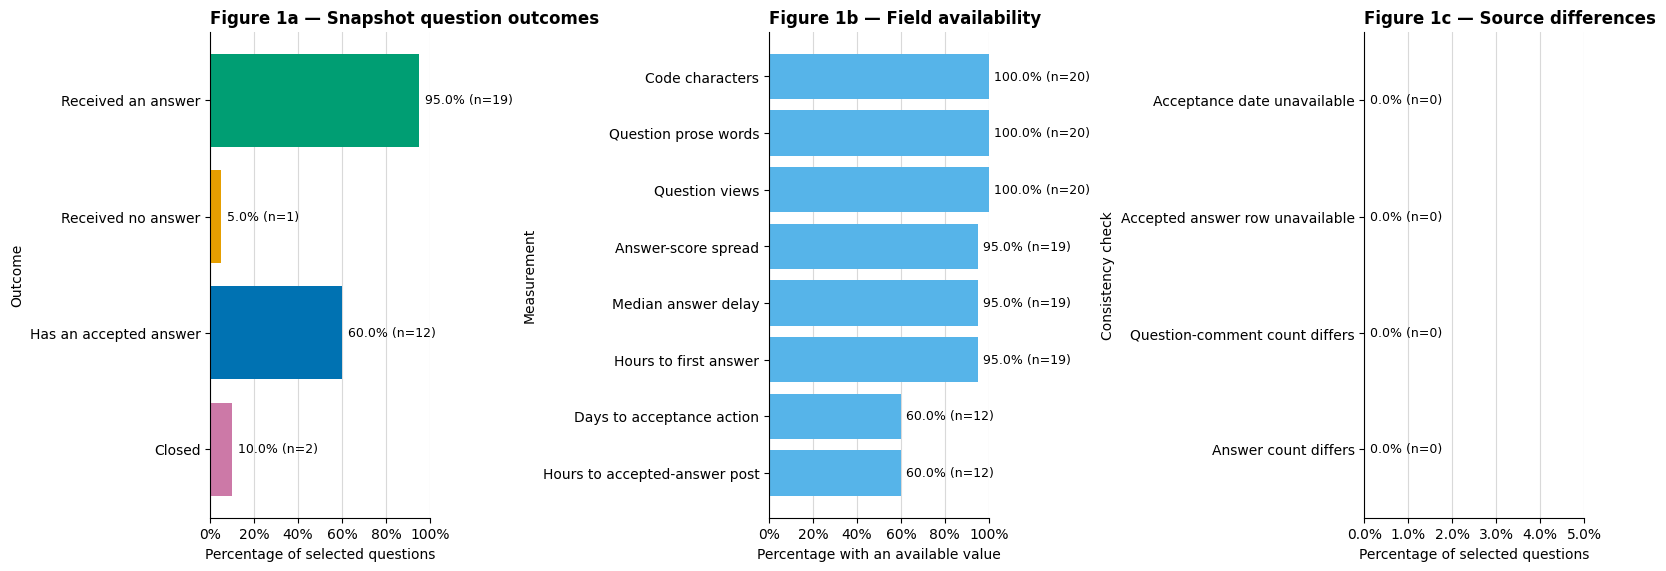

,Check,Questions,Percentage
0,Answer count differs,0,0.0
1,Question-comment count differs,0,0.0
2,Accepted answer row unavailable,0,0.0
3,Acceptance date unavailable,0,0.0


In [4]:
outcome_summary = eda.overall_outcomes(data)
availability = eda.availability_summary(data, eda.AVAILABILITY_LABELS)
consistency = eda.consistency_summary(data)

charts.plot_overview(outcome_summary, availability, consistency)
plt.show()
display(consistency)


In [5]:
answered = outcome_summary.loc[outcome_summary["Outcome"].eq("Received an answer")].iloc[0]
accepted = outcome_summary.loc[outcome_summary["Outcome"].eq("Has an accepted answer")].iloc[0]
largest_difference = consistency.loc[consistency["Questions"].idxmax()]
display(Markdown(
    "**Figure 1 interpretation**  \n"
    f"- **{answered['Questions']:,} of {len(data):,} questions ({answered['Percentage']:.1f}%)** received an available answer.  \n"
    f"- **{accepted['Questions']:,} questions ({accepted['Percentage']:.1f}%)** have an accepted answer.  \n"
    f"- The least-available displayed measurement is **{availability.iloc[0]['Measurement']}** "
    f"with **{availability.iloc[0]['Available (%)']:.1f}%** coverage.  \n"
    f"- The largest source difference is **{largest_difference['Check']}**: "
    f"**{int(largest_difference['Questions']):,} questions**."
))
figure_status.append({"Figure": "1", "Status": "Produced", "Evidence": "Outcomes, availability, and source differences"})


**Figure 1 interpretation**  
- **19 of 20 questions (95.0%)** received an available answer.  
- **12 questions (60.0%)** have an accepted answer.  
- The least-available displayed measurement is **Hours to accepted-answer post** with **60.0%** coverage.  
- The largest source difference is **Answer count differs**: **0 questions**.

## 3. Figure 2 — Questions and snapshot outcomes by posting month and year

Monthly and annual counts are **flow values**: each period starts again at zero. Columns are therefore used, and every comparable panel starts at zero with the same vertical scale.

Answer, acceptance, and closure status describe the dump snapshot. Answered and unanswered questions are stacked because they are mutually exclusive parts of the total. Accepted and closed outcomes appear separately because they can overlap with other outcomes.


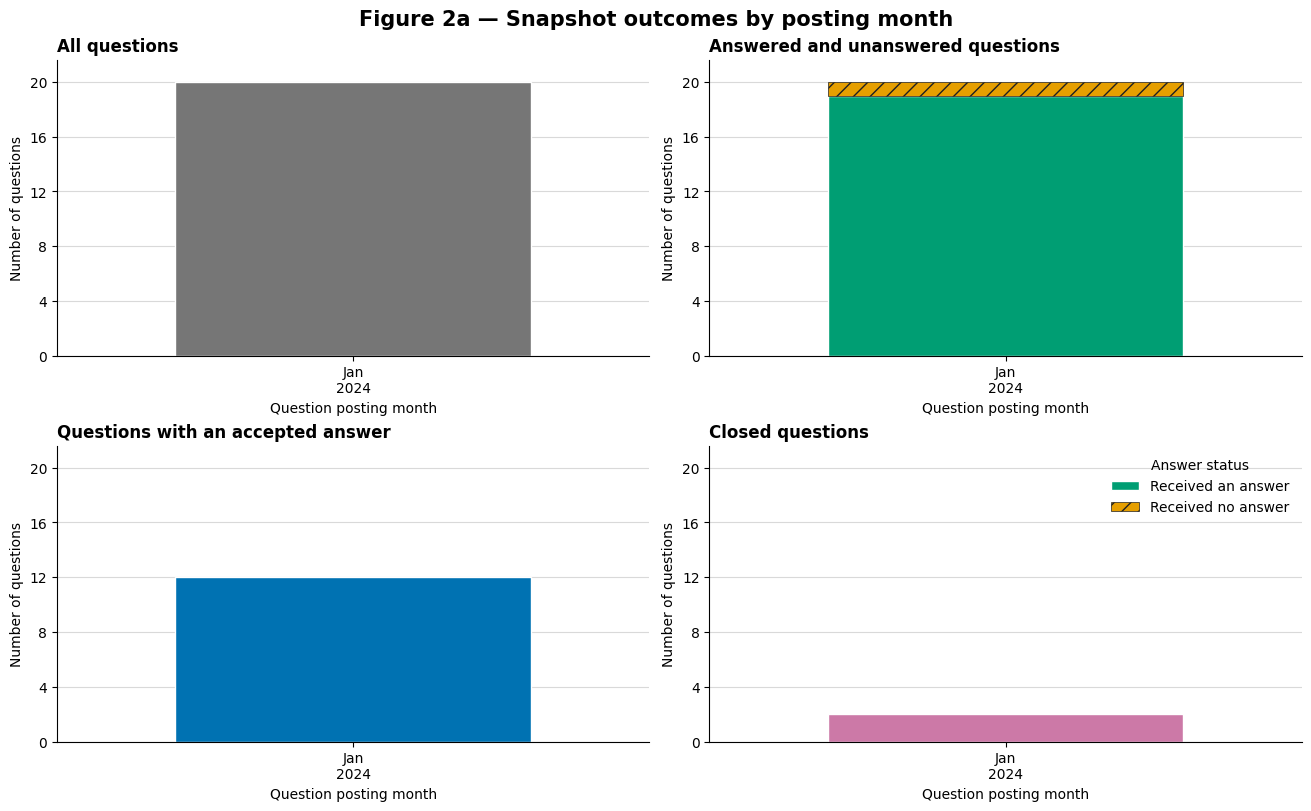

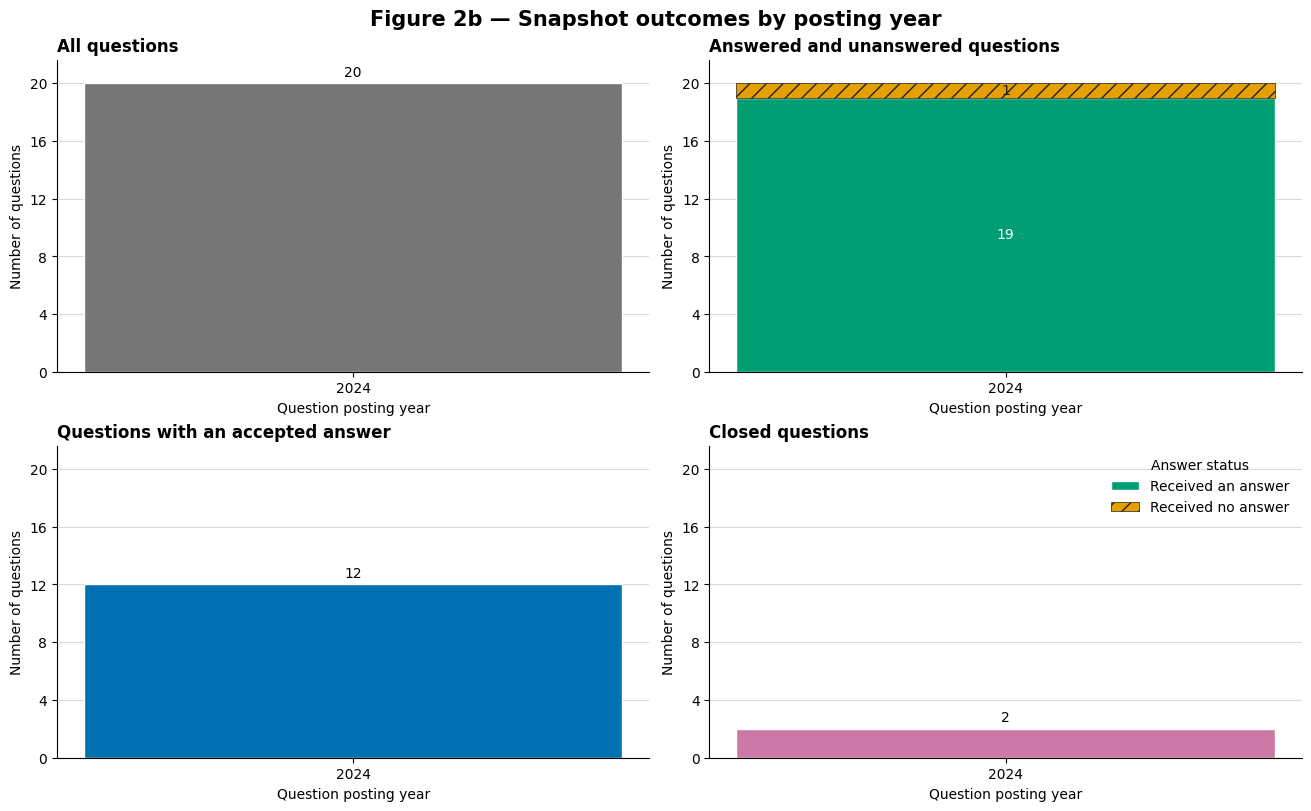

In [6]:
monthly_outcomes = eda.outcomes_by_period(data, "month")
yearly_outcomes = eda.outcomes_by_period(data, "year")

charts.plot_period_outcomes(monthly_outcomes, frequency="month", figure_label="2a")
charts.plot_period_outcomes(yearly_outcomes, frequency="year", figure_label="2b")
plt.show()


In [7]:
monthly_table = monthly_outcomes.reset_index()
monthly_table["creation_period"] = monthly_table["creation_period"].astype(str)
if len(monthly_table) <= 24:
    display(monthly_table)
else:
    display(pd.concat([monthly_table.head(12), monthly_table.tail(12)]))
display(yearly_outcomes.reset_index())

largest_month = monthly_outcomes["questions"].idxmax()
largest_year = yearly_outcomes["questions"].idxmax()
display(Markdown(
    "**Figure 2 interpretation**  \n"
    f"- **{largest_month.strftime('%B %Y')}** has the largest monthly posting cohort: "
    f"**{int(monthly_outcomes.loc[largest_month, 'questions']):,} questions**.  \n"
    f"- **{largest_year}** has the largest annual posting cohort: "
    f"**{int(yearly_outcomes.loc[largest_year, 'questions']):,} questions**.  \n"
    "- Empty calendar months remain visible as zero-count periods."
))
figure_status.append({"Figure": "2", "Status": "Produced", "Evidence": f"{len(monthly_outcomes)} months and {len(yearly_outcomes)} years"})


,creation_period,questions,answered,accepted,closed,unanswered
0,2024-01,20,19,12,2,1


,creation_period,questions,answered,accepted,closed,unanswered
0,2024,20,19,12,2,1


**Figure 2 interpretation**  
- **January 2024** has the largest monthly posting cohort: **20 questions**.  
- **2024** has the largest annual posting cohort: **20 questions**.  
- Empty calendar months remain visible as zero-count periods.

## 4. Figure 3 — Cumulative monthly evolution

Cumulative quantities are stocks or accumulated events and therefore use lines. Separate aligned panels prevent the answered/waiting partition, acceptance events, and closure events from sharing one ambiguous stacked area.

The timeline ends with the selected question period. Answers, acceptance actions, and closures recorded after that date remain outside this temporal view, even when their final snapshot status appears in Figures 1 and 2.


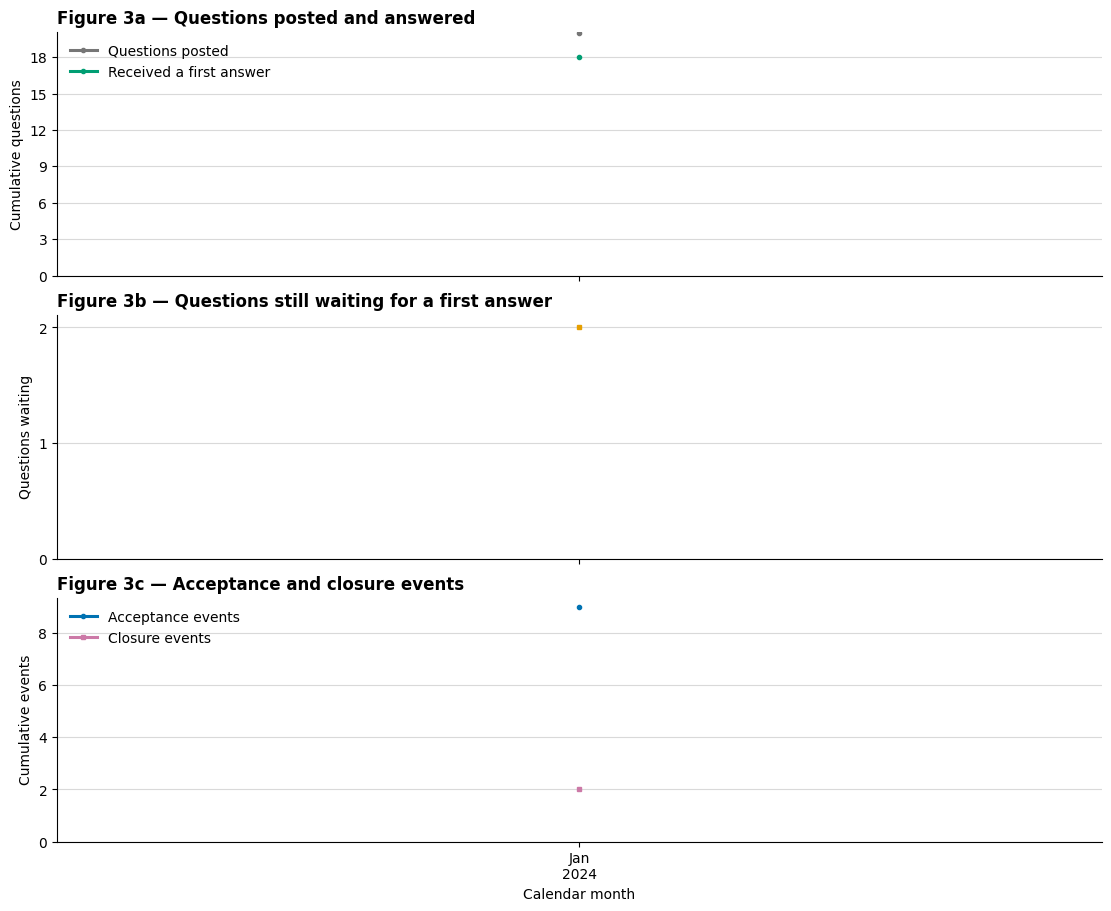

**Figure 3 interpretation**  
- The timeline covers **January 2024** through **January 2024**.  
- At the end, **18** questions had received a first answer and **2** were still waiting.  
- The period contains **9 acceptance events** and **2 closure events**.

In [8]:
cumulative = eda.cumulative_outcomes(data, analysis.analysis_end_date)
charts.plot_cumulative_outcomes(cumulative)
plt.show()

last = cumulative.iloc[-1]
display(Markdown(
    "**Figure 3 interpretation**  \n"
    f"- The timeline covers **{cumulative.index.min():%B %Y}** through **{cumulative.index.max():%B %Y}**.  \n"
    f"- At the end, **{int(last['answered']):,}** questions had received a first answer and "
    f"**{int(last['waiting']):,}** were still waiting.  \n"
    f"- The period contains **{int(last['accepted']):,} acceptance events** and "
    f"**{int(last['closed']):,} closure events**."
))
figure_status.append({"Figure": "3", "Status": "Produced", "Evidence": f"{len(cumulative)} cumulative months"})


## 5. Figure 4 — First-response evolution for every posting-month cohort

A posting-month cohort contains questions created in the same month. Every panel uses the same **0–100% scale**, so cohorts of different sizes remain comparable. The title records the cohort size.

The 49-field table contains each question's first-answer timestamp rather than every individual answer timestamp. The supported temporal result is therefore first-response acquisition: the cumulative percentage of cohort questions that had received a first available answer by each later month through the end of the selected question period.


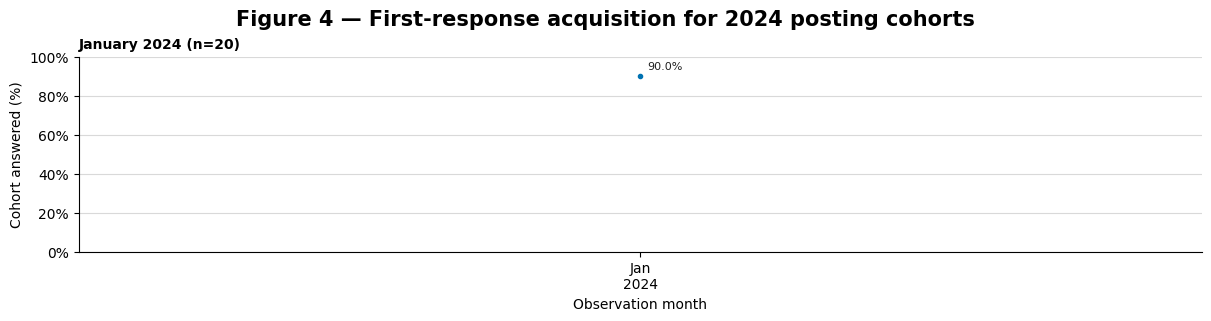

,Posting month,Questions,First answer in posting month,First answer by observation end,Answered by observation end (%)
0,2024-01,20,18,18,90.0


**Figure 4 interpretation**  
- The figure contains **1 comparable cohort panel**.  
- **2024-01** has the highest observed first-response coverage: **90.0%**.  
- The single cohort is observed through the selected period end.

In [9]:
response_evolution, response_cohort_summary = eda.first_response_cohorts(
    data, analysis.analysis_end_date
)
charts.plot_cohort_evolution(response_evolution)
plt.show()

if len(response_cohort_summary) <= 24:
    display(response_cohort_summary.round(1))
else:
    display(pd.concat([response_cohort_summary.head(12), response_cohort_summary.tail(12)]).round(1))
highest = response_cohort_summary.loc[
    response_cohort_summary["Answered by observation end (%)"].idxmax()
]
cohort_count = len(response_cohort_summary)
panel_word = "panel" if cohort_count == 1 else "panels"
follow_up_note = (
    "The single cohort is observed through the selected period end."
    if cohort_count == 1
    else "Later cohorts have shorter follow-up periods, as shown by their horizontal axes."
)
display(Markdown(
    "**Figure 4 interpretation**  \n"
    f"- The figure contains **{cohort_count:,} comparable cohort {panel_word}**.  \n"
    f"- **{highest['Posting month']}** has the highest observed first-response coverage: "
    f"**{highest['Answered by observation end (%)']:.1f}%**.  \n"
    f"- {follow_up_note}"
))
figure_status.append({"Figure": "4", "Status": "Produced", "Evidence": f"{len(response_cohort_summary)} posting-month cohorts"})


## 6. Figures 5 and 6 — Numeric distributions

Each histogram uses a linear axis and equal-width bins selected with the Freedman–Diaconis rule, limited to a readable number of bins. Integer measurements use one bin per result when the range is compact.

The shown central range is selected per measurement: 95% for long-tailed view and code volumes, 90% for long-tailed response delays, and 99% for the remaining measurements. Every panel states the number and percentage displayed. The supporting table accounts for every value outside the range and reports the full observed minimum and maximum. This preserves readable linear axes without concealing extreme observations.


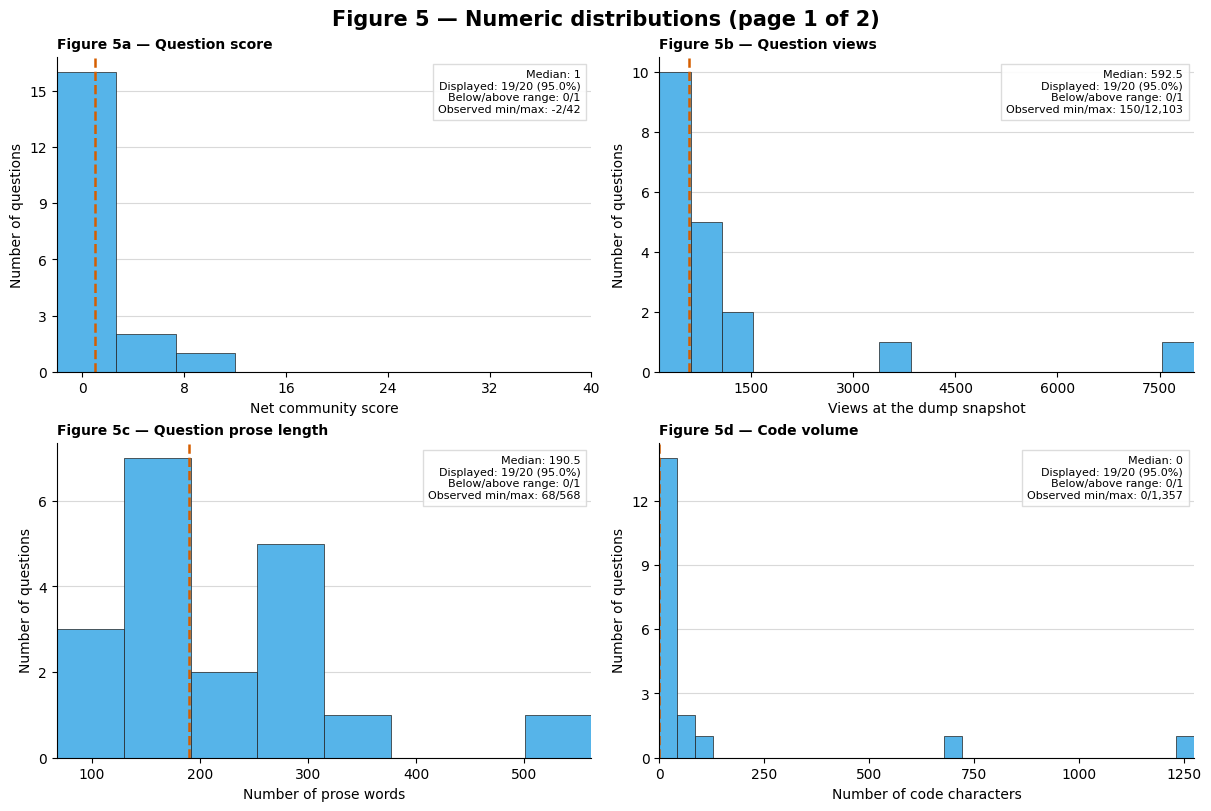

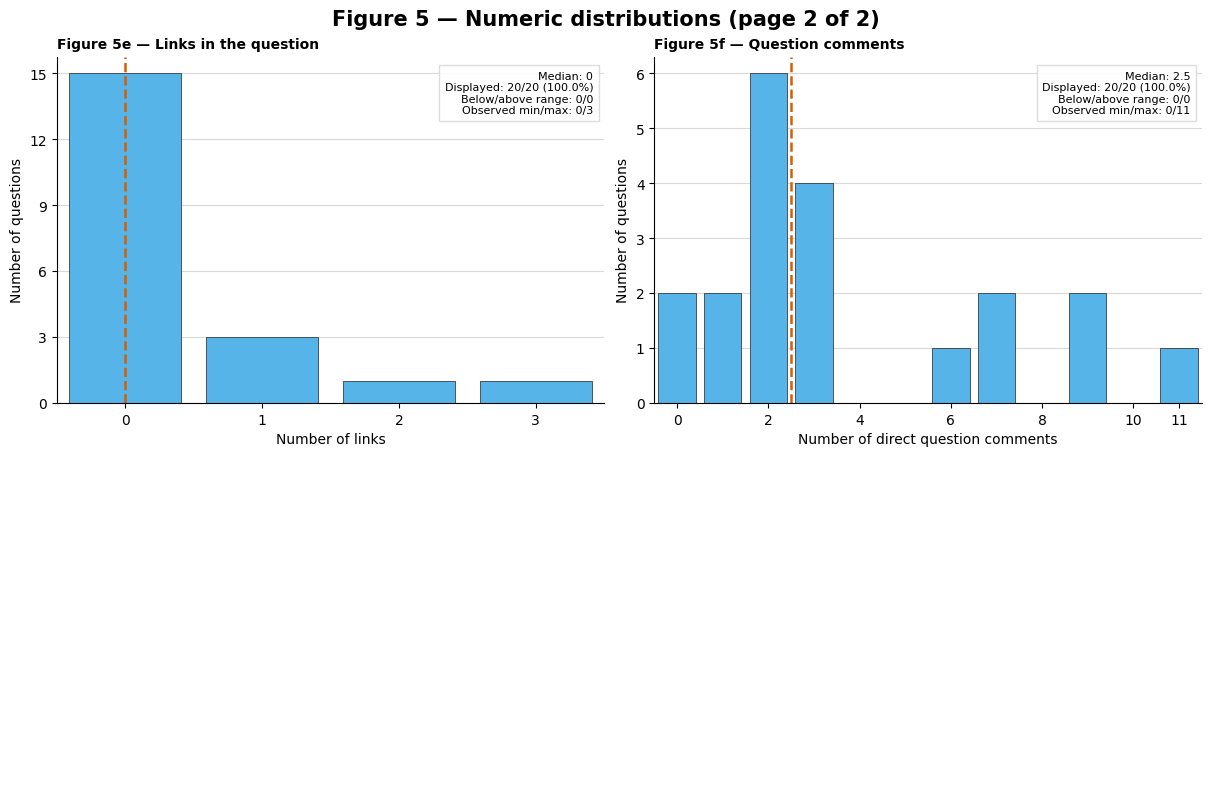

,Figure,Measurement,Available values,Displayed values,Displayed (%),Median,Shown range,Below shown range,Above shown range,Observed minimum,Observed maximum
0,5a,Question score,20,19,95.0,1.0,-2.0 to 40.0,0,1,-2.0,42.0
1,5b,Question views,20,19,95.0,592.5,"150.0 to 8,002.0",0,1,150.0,12103.0
2,5c,Question prose length,20,19,95.0,190.5,68.0 to 562.0,0,1,68.0,568.0
3,5d,Code volume,20,19,95.0,0.0,"0.0 to 1,273.0",0,1,0.0,1357.0
4,5e,Links in the question,20,20,100.0,0.0,0.0 to 3.0,0,0,0.0,3.0
5,5f,Question comments,20,20,100.0,2.5,0.0 to 11.0,0,0,0.0,11.0


**Figure 5 interpretation.** Every panel uses actual content units and a zero-based or signed linear range. The table records the complete tail accounting for each displayed histogram.

In [10]:
content_figures, content_profiles = charts.plot_distributions(
    data, eda.CONTENT_DISTRIBUTIONS, figure_number="5"
)
plt.show()
content_distribution_table = eda.distribution_summary_table(content_profiles)
display(content_distribution_table.round(1))
display(Markdown(
    "**Figure 5 interpretation.** Every panel uses actual content units and a zero-based or signed linear range. "
    "The table records the complete tail accounting for each displayed histogram."
))
figure_status.append({"Figure": "5", "Status": "Produced", "Evidence": "Six content distributions on two readable pages"})


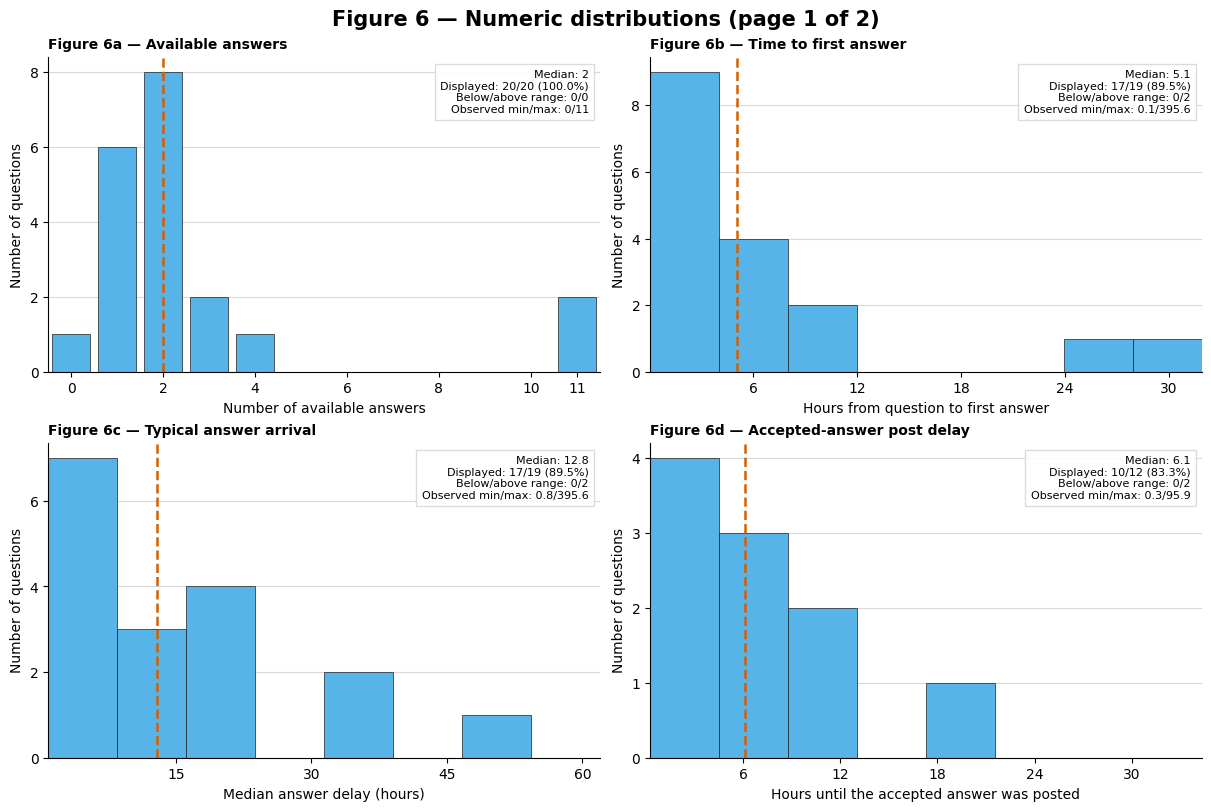

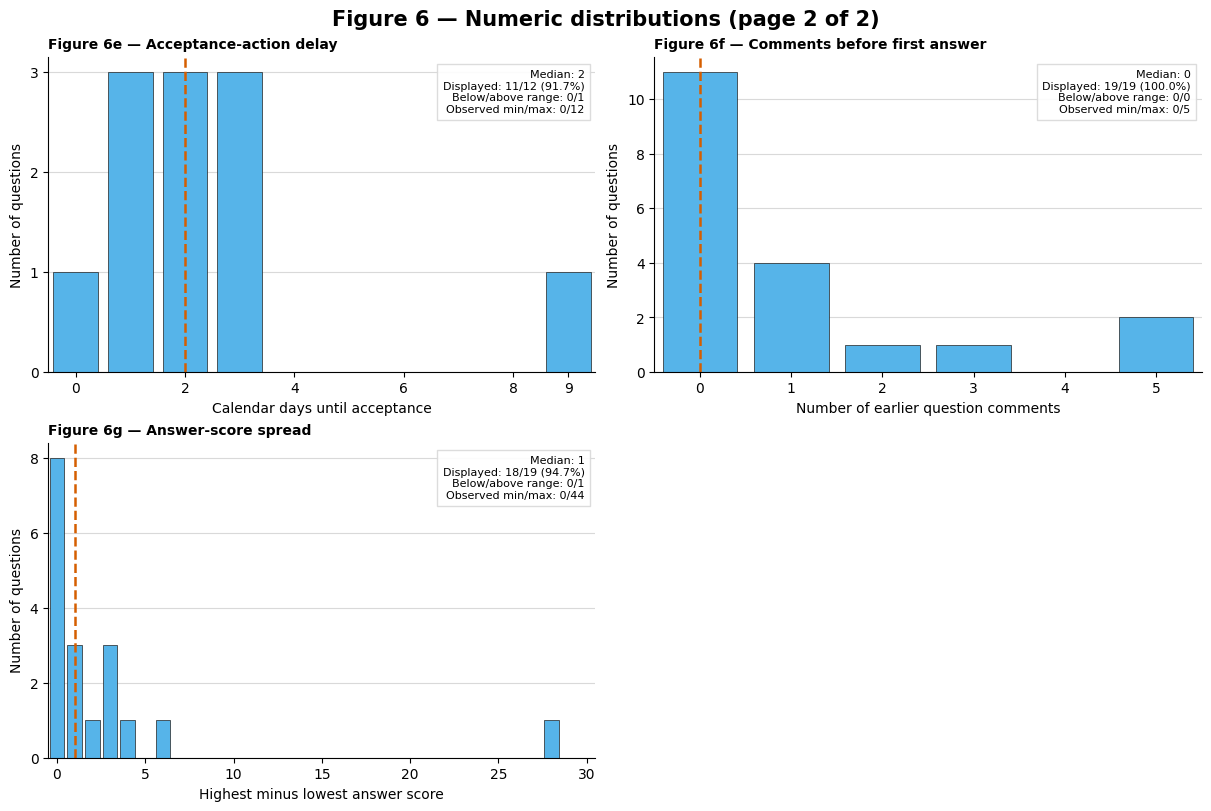

,Figure,Measurement,Available values,Displayed values,Displayed (%),Median,Shown range,Below shown range,Above shown range,Observed minimum,Observed maximum
0,6a,Available answers,20,20,100.0,2.0,0.0 to 11.0,0,0,0.0,11.0
1,6b,Time to first answer,19,17,89.5,5.1,0.1 to 31.9,0,2,0.1,395.6
2,6c,Typical answer arrival,19,17,89.5,12.8,0.8 to 61.9,0,2,0.8,395.6
3,6d,Accepted-answer post delay,12,10,83.3,6.1,0.3 to 34.3,0,2,0.3,95.9
4,6e,Acceptance-action delay,12,11,91.7,2.0,0.0 to 9.0,0,1,0.0,12.0
5,6f,Comments before first answer,19,19,100.0,0.0,0.0 to 5.0,0,0,0.0,5.0
6,6g,Answer-score spread,19,18,94.7,1.0,0.0 to 30.0,0,1,0.0,44.0


**Figure 6 interpretation.** Response and resolution delays are strongly right-skewed when the median is near the left side and the reported maximum greatly exceeds the shown upper limit. Empty values represent questions for which the corresponding event did not occur or was unavailable.

In [11]:
response_figures, response_profiles = charts.plot_distributions(
    data, eda.RESPONSE_DISTRIBUTIONS, figure_number="6"
)
plt.show()
response_distribution_table = eda.distribution_summary_table(response_profiles)
display(response_distribution_table.round(1))
display(Markdown(
    "**Figure 6 interpretation.** Response and resolution delays are strongly right-skewed when the median is "
    "near the left side and the reported maximum greatly exceeds the shown upper limit. Empty values represent "
    "questions for which the corresponding event did not occur or was unavailable."
))
figure_status.append({"Figure": "6", "Status": "Produced", "Evidence": "Seven response distributions on two readable pages"})


## 7. Figure 7 — Tukey high-outlier evidence

**Question notation.** `Q_i` denotes the question represented by row `i`; it is not a composite difficulty score.

**Method.** A measurement receives a high-outlier flag above `Q3 + 1.5 × IQR`, where `IQR = Q3 − Q1`. Figure 7a uses **available values for that measurement** as its denominator. Figure 7b shows how many measurement-specific flags occur on each question.

A statistical outlier is an inspection candidate. Data-error and difficulty classifications require separate evidence.


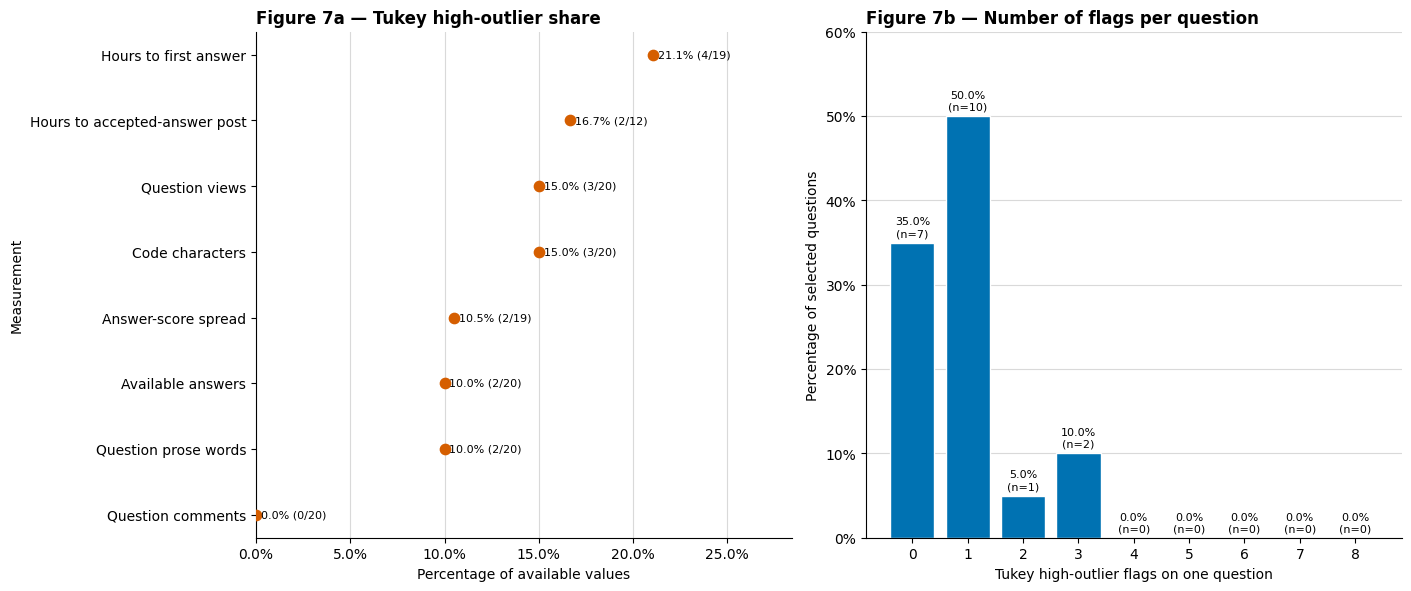

,Measurement,Available values,Q1 (25th percentile),Q3 (75th percentile),High-outlier threshold,High outliers,Share of available values (%)
0,Question views,20,316.5,957.8,1919.6,3,15.0
1,Question prose words,20,153.0,268.2,441.1,2,10.0
2,Code characters,20,0.0,62.2,155.6,3,15.0
3,Available answers,20,1.0,2.2,4.1,2,10.0
4,Question comments,20,2.0,6.2,12.6,0,0.0
5,Hours to first answer,19,1.3,10.5,24.3,4,21.1
6,Hours to accepted-answer post,12,1.7,13.2,30.3,2,16.7
7,Answer-score spread,19,0.0,3.0,7.5,2,10.5


**Figure 7 interpretation**  
- **Hours to first answer** has the largest high-outlier share: **4 of 19 available values (21.1%)**.  
- The separate dataset contains **13 questions**.  
- **Outlier result:** In-memory dataset: outlier_questions.

In [12]:
outlier_summary, outlier_flags = eda.tukey_high_outliers(data, eda.OUTLIER_LABELS)
charts.plot_outlier_evidence(outlier_summary, outlier_flags)
plt.show()
display(outlier_summary.round(1))

outlier_questions, outlier_export_status = eda.build_outlier_dataset(
    data,
    analysis.source_columns,
    outlier_flags,
    eda.OUTLIER_LABELS,
    OUTLIER_OUTPUT_FILE,
)
largest = outlier_summary.loc[outlier_summary["Share of available values (%)"].idxmax()]
display(Markdown(
    "**Figure 7 interpretation**  \n"
    f"- **{largest['Measurement']}** has the largest high-outlier share: "
    f"**{int(largest['High outliers']):,} of {int(largest['Available values']):,} available values "
    f"({largest['Share of available values (%)']:.1f}%)**.  \n"
    f"- The separate dataset contains **{len(outlier_questions):,} questions**.  \n"
    f"- **Outlier result:** {outlier_export_status}."
))
figure_status.append({"Figure": "7", "Status": "Produced", "Evidence": f"{len(outlier_summary)} thresholds and {len(outlier_questions)} flagged questions"})


## 8. Figure 8 — Patterns in the separate outlier dataset

The former comparison mixed the outlier subset into the “all questions” baseline. Figure 8 now uses two **mutually exclusive groups**: questions with no high-outlier flag and questions with at least one flag.

Figure 8a compares outcome percentages. Figure 8b compares the prevalence of frequent outlier-subset tags against the unflagged group. Connected dots emphasize the percentage-point difference without implying causation.


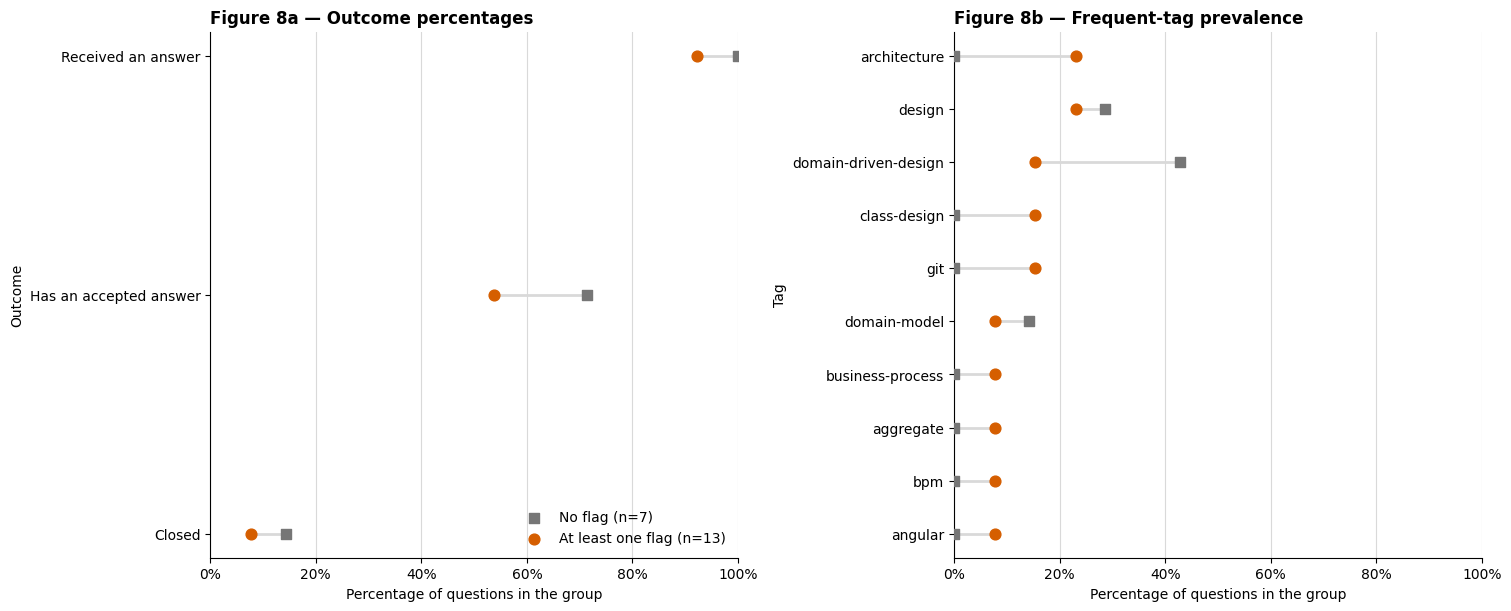

,Group,Group size,Outcome,Questions,Percentage
0,No high-outlier flag,7,Received an answer,7,100.0
1,No high-outlier flag,7,Has an accepted answer,5,71.4
2,No high-outlier flag,7,Closed,1,14.3
3,At least one high-outlier flag,13,Received an answer,12,92.3
4,At least one high-outlier flag,13,Has an accepted answer,7,53.8
5,At least one high-outlier flag,13,Closed,1,7.7


Group,Flagged questions,Unflagged questions,Flagged prevalence (%),Unflagged prevalence (%),Difference (percentage points)
tag,,,,,
angular,1,0,7.7,0.0,7.7
bpm,1,0,7.7,0.0,7.7
aggregate,1,0,7.7,0.0,7.7
business-process,1,0,7.7,0.0,7.7
domain-model,1,1,7.7,14.3,-6.6
git,2,0,15.4,0.0,15.4
class-design,2,0,15.4,0.0,15.4
domain-driven-design,2,3,15.4,42.9,-27.5
design,3,2,23.1,28.6,-5.5


**Figure 8 interpretation**  
- Flagged and unflagged groups contain **13** and **7** questions.  
- The largest displayed outcome gap concerns **Has an accepted answer**: **-17.6 percentage points** for flagged questions.  
- Tag differences identify topics for inspection; they do not establish a causal effect.

In [13]:
outlier_outcomes = eda.outlier_group_outcomes(data, outlier_flags)
outlier_tags = eda.outlier_tag_prevalence(
    data, outlier_flags, limit=min(10, TOP_TAGS_TO_SHOW)
)

outlier_group_sizes = outlier_outcomes.groupby("Group")["Group size"].first()
comparable_outlier_groups = outlier_group_sizes.gt(0).all()

if not comparable_outlier_groups:
    display(Markdown(
        "**Figure 8 is unavailable.** A comparison requires at least one flagged and one unflagged question."
    ))
    figure_status.append({
        "Figure": "8", "Status": "Unavailable",
        "Evidence": "Flagged and unflagged groups are not both available",
    })
else:
    charts.plot_outlier_patterns(outlier_outcomes, outlier_tags)
    plt.show()
    display(outlier_outcomes.round(1))
    display(outlier_tags.round(1))
    comparison = outlier_outcomes.pivot(index="Outcome", columns="Group", values="Percentage")
    differences = comparison["At least one high-outlier flag"] - comparison["No high-outlier flag"]
    largest_outcome = differences.abs().idxmax()
    display(Markdown(
        "**Figure 8 interpretation**  \n"
        f"- Flagged and unflagged groups contain **{len(outlier_questions):,}** and "
        f"**{len(data) - len(outlier_questions):,}** questions.  \n"
        f"- The largest displayed outcome gap concerns **{largest_outcome}**: "
        f"**{differences[largest_outcome]:+.1f} percentage points** for flagged questions.  \n"
        "- Tag differences identify topics for inspection; they do not establish a causal effect."
    ))
    figure_status.append({"Figure": "8", "Status": "Produced", "Evidence": "Mutually exclusive outcome and tag comparisons"})


## 9. Figure 9 — Curated Spearman relationships

Spearman correlation measures whether two characteristics tend to rise or fall together after raw values are replaced by ranks.

Each pair requires at least `MIN_CORRELATION_OBSERVATIONS` complete questions. Retained pairs also satisfy the absolute-rho and Benjamini–Hochberg false-discovery-rate limits. The dot plot replaces the former one-column heatmap: every coefficient uses the same signed `−1` to `1` axis, a visible zero reference, and a numeric label. Mirrored pairs, the diagonal, and structurally redundant pairs remain absent.


In [14]:
all_correlations, meaningful_correlations = eda.spearman_relationships(
    data,
    eda.CORRELATION_LABELS,
    min_observations=MIN_CORRELATION_OBSERVATIONS,
    min_absolute_rho=MIN_ABSOLUTE_RHO,
    fdr_alpha=FDR_ALPHA,
    max_pairs=MAX_CORRELATION_PAIRS,
    excluded_pairs=eda.STRUCTURAL_CORRELATION_PAIRS,
)
correlation_figure = charts.plot_correlations(meaningful_correlations)
if correlation_figure is None:
    display(Markdown(
        "**Figure 9 is unavailable.** No pair satisfies the sample-size, strength, and false-discovery-rate rules."
    ))
    figure_status.append({"Figure": "9", "Status": "Unavailable", "Evidence": "No pair passed all rules"})
else:
    plt.show()
    correlation_table = meaningful_correlations[[
        "pair_label", "rho", "observations", "q_value"
    ]].rename(columns={
        "pair_label": "Characteristic pair", "rho": "Spearman rho",
        "observations": "Complete questions", "q_value": "FDR q-value",
    })
    display(correlation_table.round(3))
    strongest = meaningful_correlations.loc[meaningful_correlations["rho"].abs().idxmax()]
    display(Markdown(
        "**Figure 9 interpretation**  \n"
        f"- **{len(meaningful_correlations)} of {len(all_correlations)} tested pairs** are displayed.  \n"
        f"- The strongest retained pair is **{strongest['pair_label']}** with "
        f"**rho = {strongest['rho']:.2f}** across **{int(strongest['observations']):,} complete questions**.  \n"
        "- Correlation identifies association; causal conclusions require a separate study."
    ))
    figure_status.append({"Figure": "9", "Status": "Produced", "Evidence": f"{len(meaningful_correlations)} retained unique pairs"})


**Figure 9 is unavailable.** No pair satisfies the sample-size, strength, and false-discovery-rate rules.

## 10. Figure 10 — Tags and response outcomes

A question can carry several tags, so tag totals overlap across tags.

Figure 10a separates total, answered, unanswered, accepted, and closed counts into five small multiples with one common zero-based scale. Figure 10b separates the three outcome percentages into aligned dot plots. This avoids placing totals, subsets, and overlapping outcomes in one crowded bar cluster.


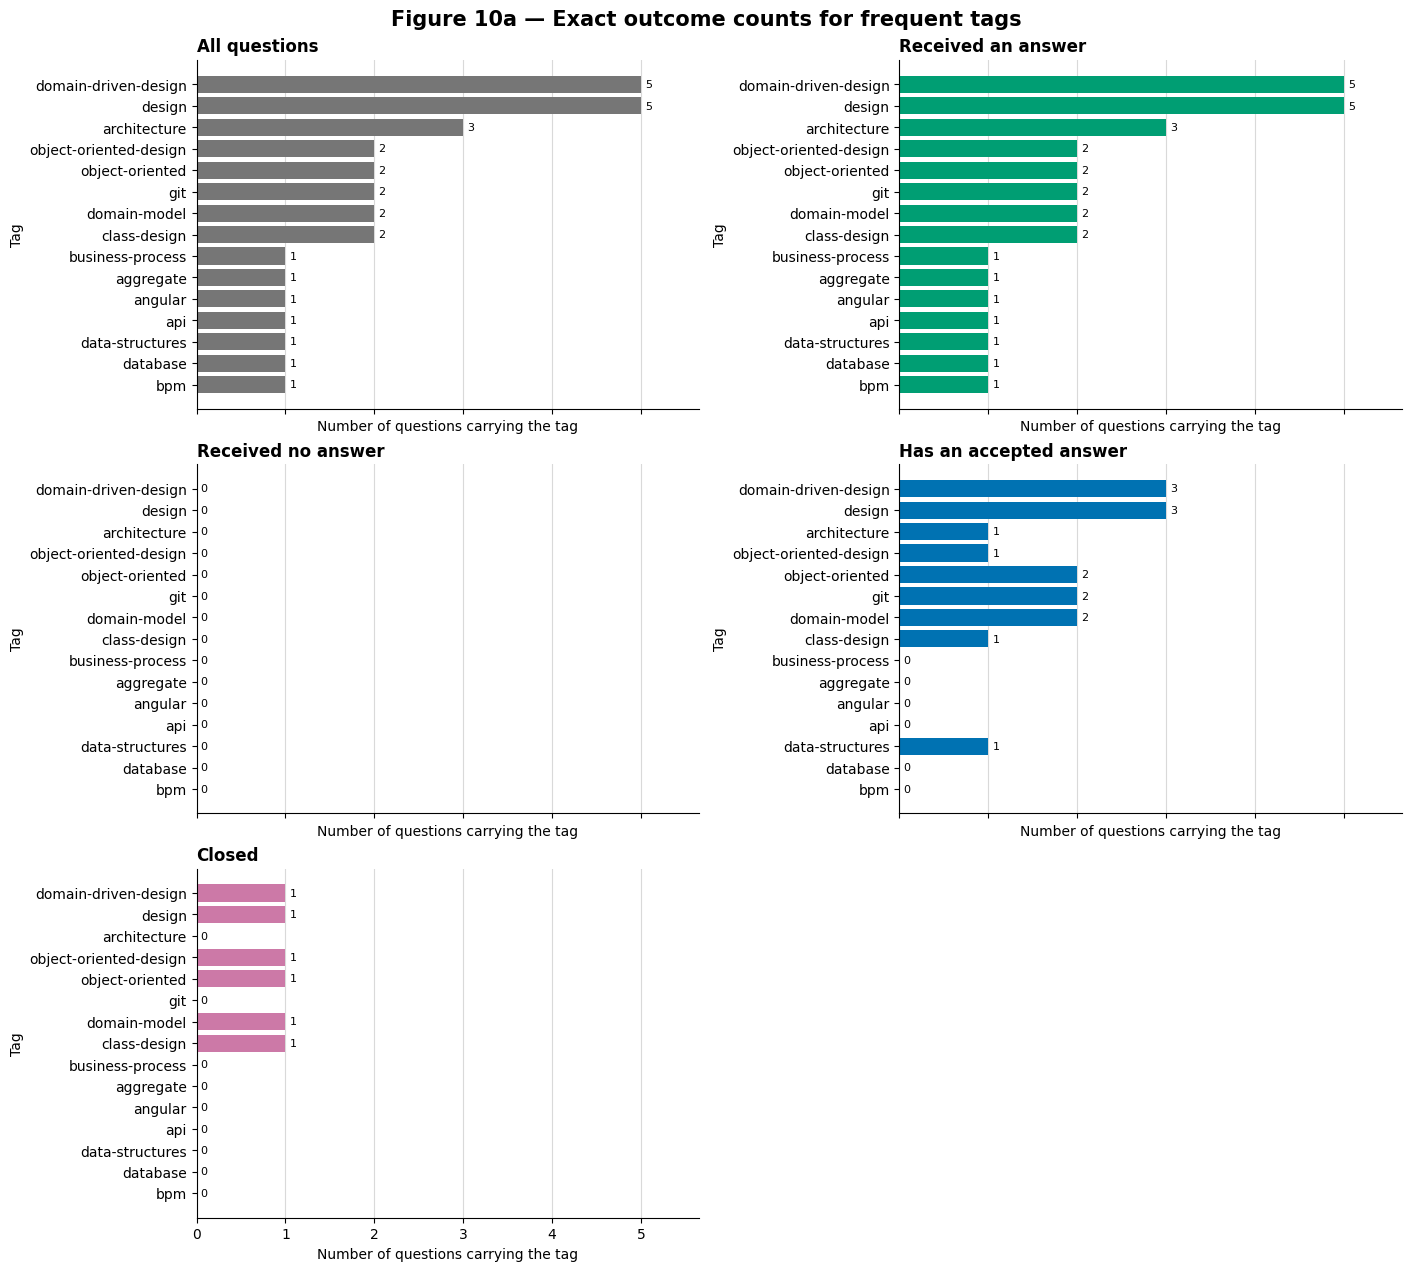

,questions,answered,accepted,closed,unanswered,answered_percentage,accepted_percentage,closed_percentage
tag,,,,,,,,
design,5,5,3,1,0,100.0,60.0,20.0
domain-driven-design,5,5,3,1,0,100.0,60.0,20.0
architecture,3,3,1,0,0,100.0,33.3,0.0
class-design,2,2,1,1,0,100.0,50.0,50.0
domain-model,2,2,2,1,0,100.0,100.0,50.0
git,2,2,2,0,0,100.0,100.0,0.0
object-oriented,2,2,2,1,0,100.0,100.0,50.0
object-oriented-design,2,2,1,1,0,100.0,50.0,50.0
business-process,1,1,0,0,0,100.0,0.0,0.0


**Figure 10 interpretation.** Exact counts are shown. No tag reaches the minimum of **20 questions** required for the percentage comparison.

In [15]:
tag_summary = eda.tag_outcomes(data)
top_tags = tag_summary.head(TOP_TAGS_TO_SHOW)
eligible_tags = tag_summary[tag_summary["questions"].ge(MIN_TAG_QUESTIONS)].head(TOP_TAGS_TO_SHOW)

tag_count_figure = charts.plot_tag_counts(top_tags)
tag_percentage_figure = charts.plot_tag_percentages(eligible_tags, MIN_TAG_QUESTIONS)
if tag_count_figure is not None:
    plt.show()
    display(top_tags.round(1))

if top_tags.empty:
    display(Markdown("**Figure 10 is unavailable.** The selected questions contain no tags."))
    figure_status.append({"Figure": "10", "Status": "Unavailable", "Evidence": "No tags"})
elif tag_percentage_figure is None:
    display(Markdown(
        f"**Figure 10 interpretation.** Exact counts are shown. No tag reaches the "
        f"minimum of **{MIN_TAG_QUESTIONS} questions** required for the percentage comparison."
    ))
    figure_status.append({"Figure": "10", "Status": "Partial", "Evidence": "Exact counts available; no eligible percentage groups"})
else:
    most_frequent = tag_summary.index[0]
    highest = eligible_tags["answered_percentage"].idxmax()
    lowest = eligible_tags["answered_percentage"].idxmin()
    display(Markdown(
        "**Figure 10 interpretation**  \n"
        f"- **{most_frequent}** is the most frequent tag with "
        f"**{int(tag_summary.loc[most_frequent, 'questions']):,} questions**.  \n"
        f"- Among eligible tags, **{highest}** has the highest answered percentage "
        f"(**{eligible_tags.loc[highest, 'answered_percentage']:.1f}%**) and **{lowest}** has the lowest "
        f"(**{eligible_tags.loc[lowest, 'answered_percentage']:.1f}%**).  \n"
        "- Exact counts remain available in the displayed table."
    ))
    figure_status.append({"Figure": "10", "Status": "Produced", "Evidence": f"{len(top_tags)} frequent and {len(eligible_tags)} eligible tags"})


## 11. High-outlier questions selected for inspection

The table links Tukey flags to concrete questions. Rows with several flagged measurements receive priority, followed by long first-answer delays and high question-comment counts. These entries support qualitative inspection. Difficulty labels require a documented manual assessment.


In [16]:
if outlier_questions.empty:
    display(Markdown("No high-outlier question is available for the final inspection table."))
else:
    cases = outlier_questions.sort_values(
        ["high_outlier_field_count", "time_to_first_answer_hours", "available_question_comment_count"],
        ascending=[False, False, False],
        na_position="last",
    ).head(MAX_CASES_TO_SHOW).copy()
    cases["question_title"] = cases["question_title"].fillna("").str.slice(0, 90)
    display(cases[[
        "high_outlier_measurements", "high_outlier_field_count", "question_id",
        "question_title", "question_url", "available_answer_count",
        "available_question_comment_count", "time_to_first_answer_hours",
    ]].rename(columns={
        "high_outlier_measurements": "High-outlier measurements",
        "high_outlier_field_count": "Tukey flags", "question_id": "Question ID",
        "question_title": "Question title (first 90 characters)",
        "question_url": "Question URL", "available_answer_count": "Available answers",
        "available_question_comment_count": "Question comments",
        "time_to_first_answer_hours": "Hours to first answer",
    }))


,High-outlier measurements,Tukey flags,Question ID,Question title (first 90 characters),Question URL,Available answers,Question comments,Hours to first answer
8,Question views; Available answers; Answer-scor...,3,450386,Where to keep the code that I do not want in t...,https://softwareengineering.stackexchange.com/...,11,7,0.251918
7,Question views; Available answers; Answer-scor...,3,450379,What do you do with branches you've abandoned?,https://softwareengineering.stackexchange.com/...,11,2,0.143861
2,Hours to first answer; Hours to accepted-answe...,2,450359,Offering multiple versions of artifact heavy p...,https://softwareengineering.stackexchange.com/...,2,1,35.570644
1,Hours to first answer,1,450356,How to make a hierarchical permission architec...,https://softwareengineering.stackexchange.com/...,1,3,395.622293
12,Hours to first answer,1,450414,Orchestrator (like Camunda) between frontend a...,https://softwareengineering.stackexchange.com/...,2,3,30.985681
4,Hours to first answer,1,450361,Splitting up large SQLAlchemy model,https://softwareengineering.stackexchange.com/...,2,1,27.169258
6,Code characters,1,450374,Should domain services in a domain-driven desi...,https://softwareengineering.stackexchange.com/...,1,2,9.218981
0,Hours to accepted-answer post,1,450355,What was the first company to make a drag-and-...,https://softwareengineering.stackexchange.com/...,3,9,7.690655


## 12. Run status

The final table records which figure groups were produced, partially available, or unavailable because the selected data did not contain enough evidence.


In [17]:
status_table = pd.DataFrame(figure_status)
display(status_table)
input_display = DATA_FILE.relative_to(PROJECT_ROOT) if DATA_FILE.is_relative_to(PROJECT_ROOT) else DATA_FILE
produced = int(status_table["Status"].eq("Produced").sum())
partial = int(status_table["Status"].eq("Partial").sum())
unavailable = int(status_table["Status"].eq("Unavailable").sum())
display(Markdown(
    "**Run complete**  \n"
    f"- Input file: `{input_display}`  \n"
    f"- Source table: **{analysis.source_row_count:,} rows × {analysis.source_column_count:,} columns**  \n"
    f"- Selected period: **{analysis.requested_period}**  \n"
    f"- Questions analyzed: **{len(data):,}**  \n"
    f"- Separate high-outlier dataset: **{len(outlier_questions):,} questions**  \n"
    f"- Outlier result: **{outlier_export_status}**  \n"
    f"- Figure groups produced/partial/unavailable: **{produced}/{partial}/{unavailable}**  \n"
    "- Execution reached the final cell without a notebook exception."
))


,Figure,Status,Evidence
0,1,Produced,"Outcomes, availability, and source differences"
1,2,Produced,1 months and 1 years
2,3,Produced,1 cumulative months
3,4,Produced,1 posting-month cohorts
4,5,Produced,Six content distributions on two readable pages
5,6,Produced,Seven response distributions on two readable p...
6,7,Produced,8 thresholds and 13 flagged questions
7,8,Produced,Mutually exclusive outcome and tag comparisons
8,9,Unavailable,No pair passed all rules
9,10,Partial,Exact counts available; no eligible percentage...


**Run complete**  
- Input file: `data/examples/characteristics_pilot.tsv`  
- Source table: **20 rows × 49 columns**  
- Selected period: **All question rows in the TSV**  
- Questions analyzed: **20**  
- Separate high-outlier dataset: **13 questions**  
- Outlier result: **In-memory dataset: outlier_questions**  
- Figure groups produced/partial/unavailable: **8/1/1**  
- Execution reached the final cell without a notebook exception.